In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pandas as pd
from PIL import Image

In [2]:
root_path = r"D:\Project\CPV_paper\datasets\raw\OfficeHome\DG_Benchmark"
root = os.listdir(root_path)

In [3]:
rows = []

for domain in os.listdir(root_path):
    domain_path = os.path.join(root_path, domain)

    if not os.path.isdir(domain_path):
        continue

    for category in os.listdir(domain_path):
        category_path = os.path.join(domain_path, category)

        if not os.path.isdir(category_path):
            continue

        for image in os.listdir(category_path):
            image_path = os.path.join(category_path, image)

            if not os.path.isfile(image_path):
                continue

            rows.append({
                "image_path": image_path,
                "image_name": image,
                "domain": domain,
                "category": category
            })

df = pd.DataFrame(rows)

df.head()

,image_path,image_name,domain,category
0,D:\Project\CPV_paper\datasets\raw\OfficeHome\D...,00001.jpg,Art,Alarm_Clock
1,D:\Project\CPV_paper\datasets\raw\OfficeHome\D...,00002.jpg,Art,Alarm_Clock
2,D:\Project\CPV_paper\datasets\raw\OfficeHome\D...,00003.jpg,Art,Alarm_Clock
3,D:\Project\CPV_paper\datasets\raw\OfficeHome\D...,00004.jpg,Art,Alarm_Clock
4,D:\Project\CPV_paper\datasets\raw\OfficeHome\D...,00005.jpg,Art,Alarm_Clock


In [4]:
print(f"""
Number of domains: {len(df['domain'].unique())}
{df['domain'].unique()}

Number of categories: {len(df['category'].unique())}
{df['category'].unique()}

Number of images: {len(df)}
""")


Number of domains: 4
['Art' 'Clipart' 'Product' 'Real World']

Number of categories: 65
['Alarm_Clock' 'Backpack' 'Batteries' 'Bed' 'Bike' 'Bottle' 'Bucket'
 'Calculator' 'Calendar' 'Candles' 'Chair' 'Clipboards' 'Computer' 'Couch'
 'Curtains' 'Desk_Lamp' 'Drill' 'Eraser' 'Exit_Sign' 'Fan' 'File_Cabinet'
 'Flipflops' 'Flowers' 'Folder' 'Fork' 'Glasses' 'Hammer' 'Helmet'
 'Kettle' 'Keyboard' 'Knives' 'Lamp_Shade' 'Laptop' 'Marker' 'Monitor'
 'Mop' 'Mouse' 'Mug' 'Notebook' 'Oven' 'Pan' 'Paper_Clip' 'Pen' 'Pencil'
 'Postit_Notes' 'Printer' 'Push_Pin' 'Radio' 'Refrigerator' 'Ruler'
 'Scissors' 'Screwdriver' 'Shelf' 'Sink' 'Sneakers' 'Soda' 'Speaker'
 'Spoon' 'Table' 'Telephone' 'ToothBrush' 'Toys' 'Trash_Can' 'TV' 'Webcam']

Number of images: 15588



In [5]:
def bar_plot(x, y, x_label, y_label, title, data):
    plt.figure(figsize=(20, 5))
    sns.barplot(x=x, y=y, data=data, hue=x, palette='viridis')
    plt.xlabel(x_label)    
    plt.ylabel(y_label)
    plt.title(title)
    plt.tight_layout()
    plt.plot()


Image per domain:
       domain  count
0     Product   4439
1     Clipart   4365
2  Real World   4357
3         Art   2427

Largest domain:
domain    2
count     0
dtype: int64

Smallest domain:
domain    3
count     3
dtype: int64

Imbalance ratio:
1.83



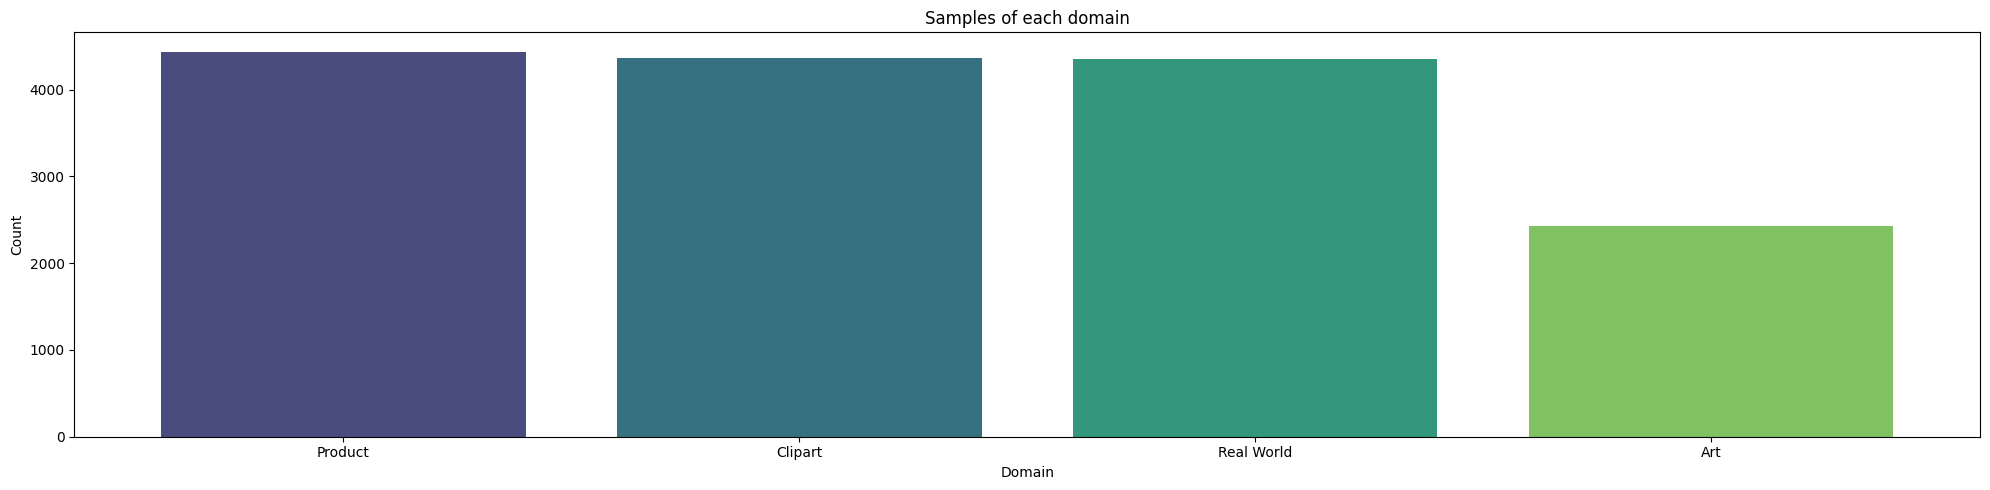

In [6]:
domain_counts = df['domain'].value_counts().reset_index()

print(f"""
Image per domain:
{domain_counts}

Largest domain:
{domain_counts.idxmax()}

Smallest domain:
{domain_counts.idxmin()}

Imbalance ratio:
{domain_counts['count'].max() / domain_counts['count'].min():.2f}
""")

bar_plot('domain', 'count', 'Domain', 'Count', 'Samples of each domain', domain_counts)


Top frequent classes:
      category  count
0        Chair    363
1      Flowers    355
2       Bottle    338
3      Candles    330
4         Bike    317
5       Laptop    316
6      Monitor    310
7     Computer    303
8  Alarm_Clock    299
9       Helmet    298

Rare classes:
        category  count
55           Mop    190
56          Fork    184
57         Ruler    181
58         Drill    181
59    Paper_Clip    174
60           Pan    170
61        Marker    170
62  Postit_Notes    165
63      Push_Pin    160
64        Eraser    142

Imbalance ratio:
2.56



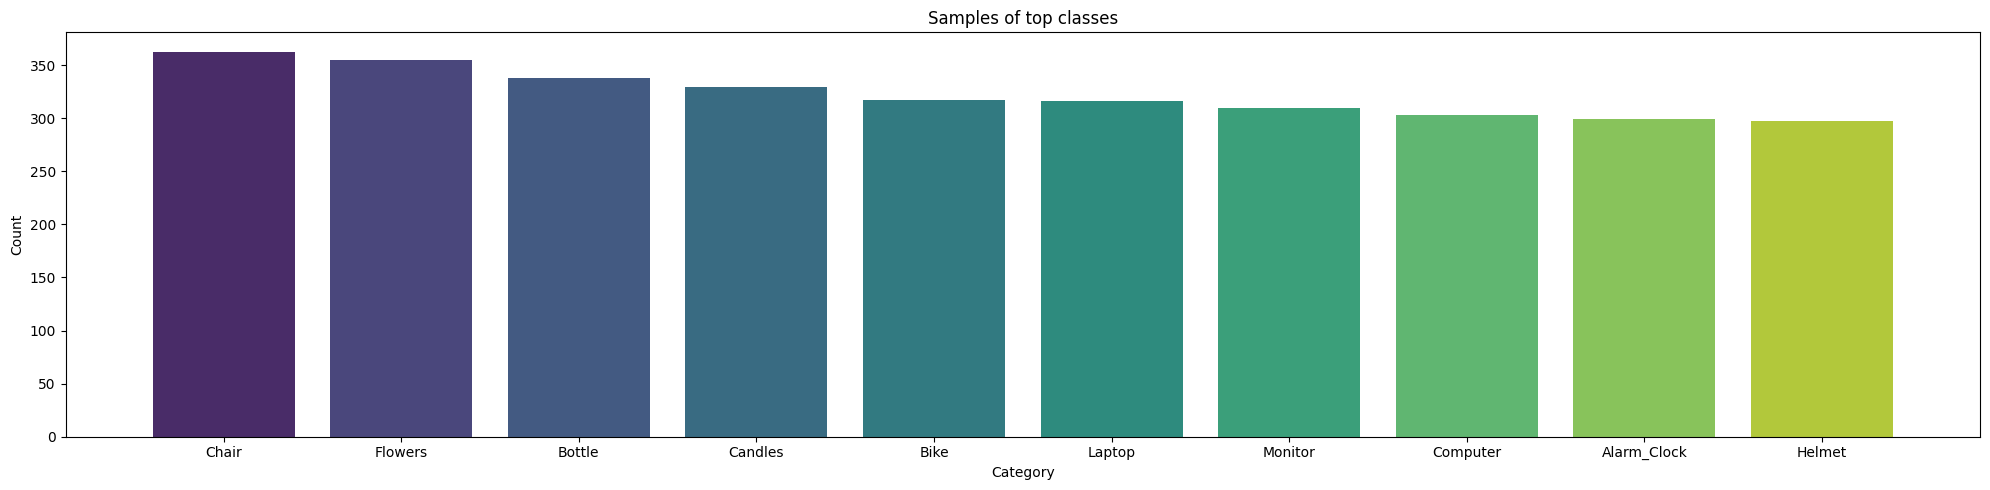

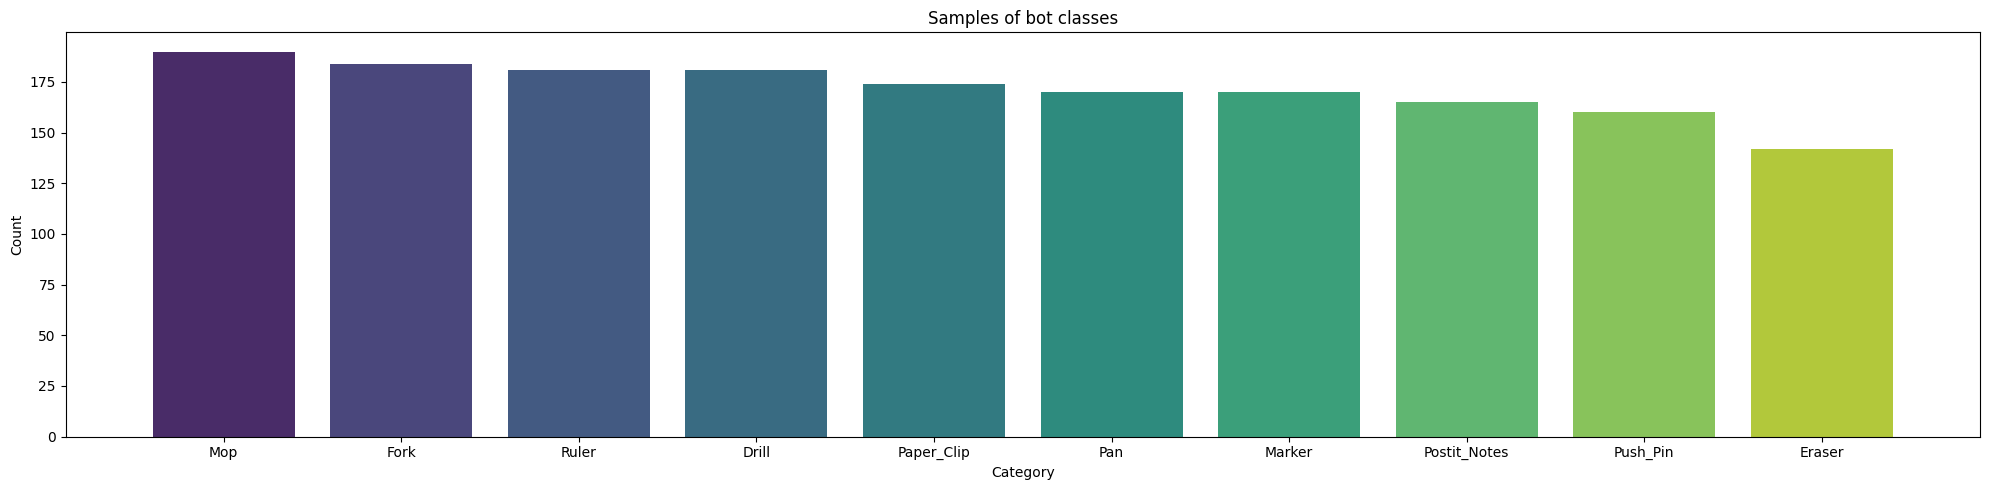

In [7]:
class_counts = df['category'].value_counts().reset_index()

print(f"""
Top frequent classes:
{class_counts.head(10)}

Rare classes:
{class_counts.tail(10)}

Imbalance ratio:
{class_counts['count'].max() / class_counts['count'].min():.2f}
""")

bar_plot('category', 'count', 'Category', 'Count', 'Samples of top classes', class_counts.head(10))
bar_plot('category', 'count', 'Category', 'Count', 'Samples of bot classes', class_counts.tail(10))

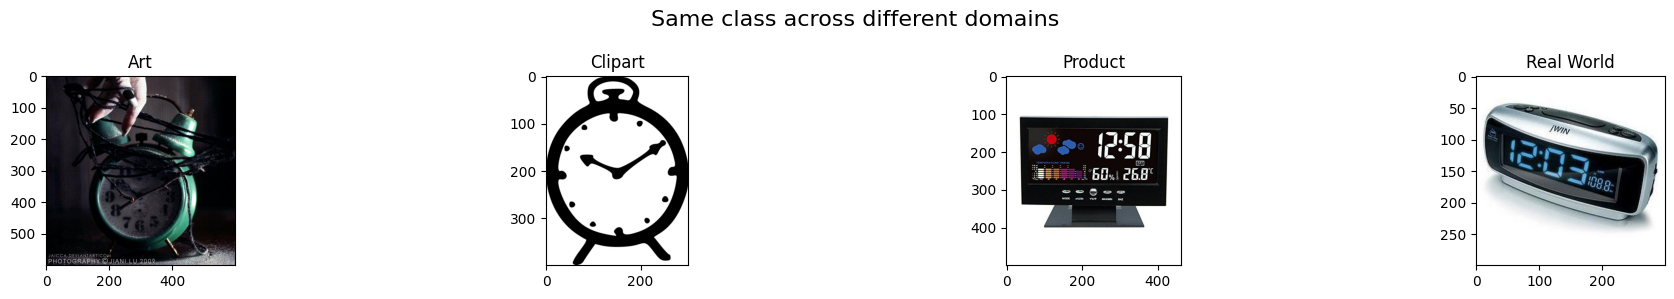

In [8]:
idx = 36
fig, ax = plt.subplots(1, 4, figsize=(20, 3))

ax[0].imshow(Image.open(df[(df['category'] == 'Alarm_Clock') & (df['domain'] == 'Art')]['image_path'].iloc[idx]))
ax[0].set_title('Art')

ax[1].imshow(Image.open(df[(df['category'] == 'Alarm_Clock') & (df['domain'] == 'Clipart')]['image_path'].iloc[idx]))
ax[1].set_title('Clipart')

ax[2].imshow(Image.open(df[(df['category'] == 'Alarm_Clock') & (df['domain'] == 'Product')]['image_path'].iloc[idx]))
ax[2].set_title('Product')

ax[3].imshow(Image.open(df[(df['category'] == 'Alarm_Clock') & (df['domain'] == 'Real World')]['image_path'].iloc[idx]))
ax[3].set_title('Real World')

plt.suptitle("Same class across different domains", fontsize=16)
plt.tight_layout()
plt.show()

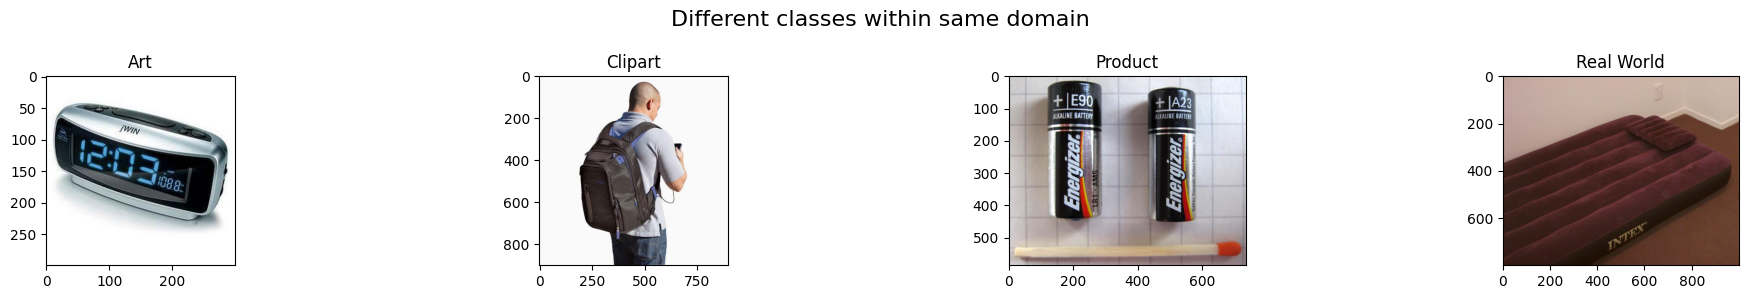

In [9]:
idx = 36
fig, ax = plt.subplots(1, 4, figsize=(20, 3))

ax[0].imshow(Image.open(df[(df['category'] == 'Alarm_Clock') & (df['domain'] == 'Real World')]['image_path'].iloc[idx]))
ax[0].set_title('Art')

ax[1].imshow(Image.open(df[(df['category'] == 'Backpack') & (df['domain'] == 'Real World')]['image_path'].iloc[idx]))
ax[1].set_title('Clipart')

ax[2].imshow(Image.open(df[(df['category'] == 'Batteries') & (df['domain'] == 'Real World')]['image_path'].iloc[idx]))
ax[2].set_title('Product')

ax[3].imshow(Image.open(df[(df['category'] == 'Bed') & (df['domain'] == 'Real World')]['image_path'].iloc[idx]))
ax[3].set_title('Real World')

plt.suptitle("Different classes within same domain", fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
widths, heights, aspect_ratios, corrupt = [], [], [], []

for path in df['image_path']:
    try:
        with Image.open(path) as img:
            img.verify()

        with Image.open(path) as img:
            w, h = img.size

        widths.append(w)
        heights.append(h)
        aspect_ratios.append(w/h)
        corrupt.append(False)

    except Exception:
        widths.append(None)
        heights.append(None)
        aspect_ratios.append(None)
        corrupt.append(True)

df = df.copy()
df["width"] = widths
df["height"] = heights
df["aspect_ratio"] = aspect_ratios
df["corrupt"] = corrupt

In [11]:
df.head()

,image_path,image_name,domain,category,width,height,aspect_ratio,corrupt
0,D:\Project\CPV_paper\datasets\raw\OfficeHome\D...,00001.jpg,Art,Alarm_Clock,900,841,1.070155,False
1,D:\Project\CPV_paper\datasets\raw\OfficeHome\D...,00002.jpg,Art,Alarm_Clock,600,450,1.333333,False
2,D:\Project\CPV_paper\datasets\raw\OfficeHome\D...,00003.jpg,Art,Alarm_Clock,900,841,1.070155,False
3,D:\Project\CPV_paper\datasets\raw\OfficeHome\D...,00004.jpg,Art,Alarm_Clock,568,663,0.856712,False
4,D:\Project\CPV_paper\datasets\raw\OfficeHome\D...,00005.jpg,Art,Alarm_Clock,900,769,1.170351,False


In [12]:
print(f"""
Image sizes stats:
{df[["width", "height", "aspect_ratio"]].describe()}

Corrupt images:
{df[df["corrupt"] == True][["image_path", "domain", "category"]]}

Small images:
{df[(df["width"] < 32) | (df["height"] < 32)][["image_path", "domain", "category", "width", "height"]]}

Strange aspect ratios images:
{df[(df["aspect_ratio"] < 0.3) | (df["aspect_ratio"] > 3.0)][["image_path", "domain", "category", "width", "height", "aspect_ratio"]].value_counts().sum()}
""")


Image sizes stats:
              width        height  aspect_ratio
count  15588.000000  15588.000000  15588.000000
mean     726.995124    649.858032      1.218679
std      646.398143    537.638259      0.823163
min       18.000000      4.000000      0.075540
25%      441.000000    400.000000      0.918000
50%      500.000000    500.000000      1.030928
75%      750.000000    662.000000      1.384216
max     6000.000000   6500.000000     35.000000

Corrupt images:
Empty DataFrame
Columns: [image_path, domain, category]
Index: []

Small images:
                                             image_path   domain     category  \
2473  D:\Project\CPV_paper\datasets\raw\OfficeHome\D...  Clipart  Alarm_Clock   
2973  D:\Project\CPV_paper\datasets\raw\OfficeHome\D...  Clipart       Bucket   
4099  D:\Project\CPV_paper\datasets\raw\OfficeHome\D...  Clipart         Fork   
4708  D:\Project\CPV_paper\datasets\raw\OfficeHome\D...  Clipart       Marker   
4709  D:\Project\CPV_paper\datasets\raw\Offic